# Single-Crystal / Directionally-Solidified (SC/DS) Alloys — Evaluation

**16 alloys, 34 datapoints, 20–1093°C** — PWA\*1480, René N5, NX188, CMSX-8/10, DD5/6/9, TMS-138/162, etc.

Four ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baseline.

**Key challenge**: ML model trained on polycrystalline alloys. SC/DS have different elastic anisotropy (⟨001⟩ ~125 GPa vs poly ~200 GPa) and can exhibit anomalous yield strength (Kear–Wilsdorf locks).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/SC_DS')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full, 'LLM': llm}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52', 'LLM': '#8172B2'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

## Table 1 — Aggregate Accuracy

In [2]:
rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df,pc,ac,10), '±20%': pct_within(df,pc,ac,20)})

tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','±10%','±20%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R²','Bias %','±10%','±20%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R²':'{:.3f}',
                              'Bias %':'{:+.1f}','±10%':'{:.0f}%','±20%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R²','±10%','±20%'], props='font-weight:bold;color:green'))


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,33,14.7,154.8,0.533,-4.1,45%,76%
ML+Phys,33,14.7,154.8,0.533,-4.1,45%,76%
Full,33,15.0,158.6,0.510,-5.1,48%,79%
LLM,33,20.4,259.9,-0.315,-15.4,48%,64%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,30,15.2,173.0,0.472,-9.3,33%,73%
ML+Phys,30,15.2,173.0,0.472,-9.3,33%,73%
Full,30,14.1,166.0,0.514,-6.0,43%,73%
LLM,30,14.7,190.4,0.360,-0.8,57%,67%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,34,118.8,7.0,0.007,+107.2,6%,18%
ML+Phys,34,119.1,7.1,-0.014,+106.9,6%,18%
Full,34,69.9,6.3,0.193,+51.2,9%,24%
LLM,34,191.4,10.5,-1.225,+177.6,15%,32%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,10,22.2,23.2,-2.103,+22.2,0%,30%
ML+Phys,10,22.2,23.2,-2.103,+22.2,0%,30%
Full,10,36.8,40.1,-8.255,+36.8,0%,0%
LLM,10,79.9,85.4,-41.086,+79.9,0%,0%


## Table 2 — Accuracy by Temperature Regime

MAPE (%) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C).

In [3]:
def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            m = metrics(sub, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAPE': m['mape']})

temp_tbl = pd.DataFrame(rows)
pivot = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAPE')
pivot = pivot[['ML', 'ML+Phys', 'Full', 'LLM']]

n_ref = temp_tbl[temp_tbl['Method']=='ML'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot = n_ref.join(pivot)
pivot.index = pivot.index.set_levels([REGIMES, ['YS', 'UTS']])

display(pivot.style.format({'n': '{:.0f}', 'ML': '{:.1f}', 'ML+Phys': '{:.1f}',
                            'Full': '{:.1f}', 'LLM': '{:.1f}'}, na_rep='\u2014')
        .highlight_min(subset=['ML', 'ML+Phys', 'Full', 'LLM'], axis=1,
                       props='font-weight:bold;color:green'))

## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions? With only 34 datapoints, these curves are noisier than SSS/Precip.

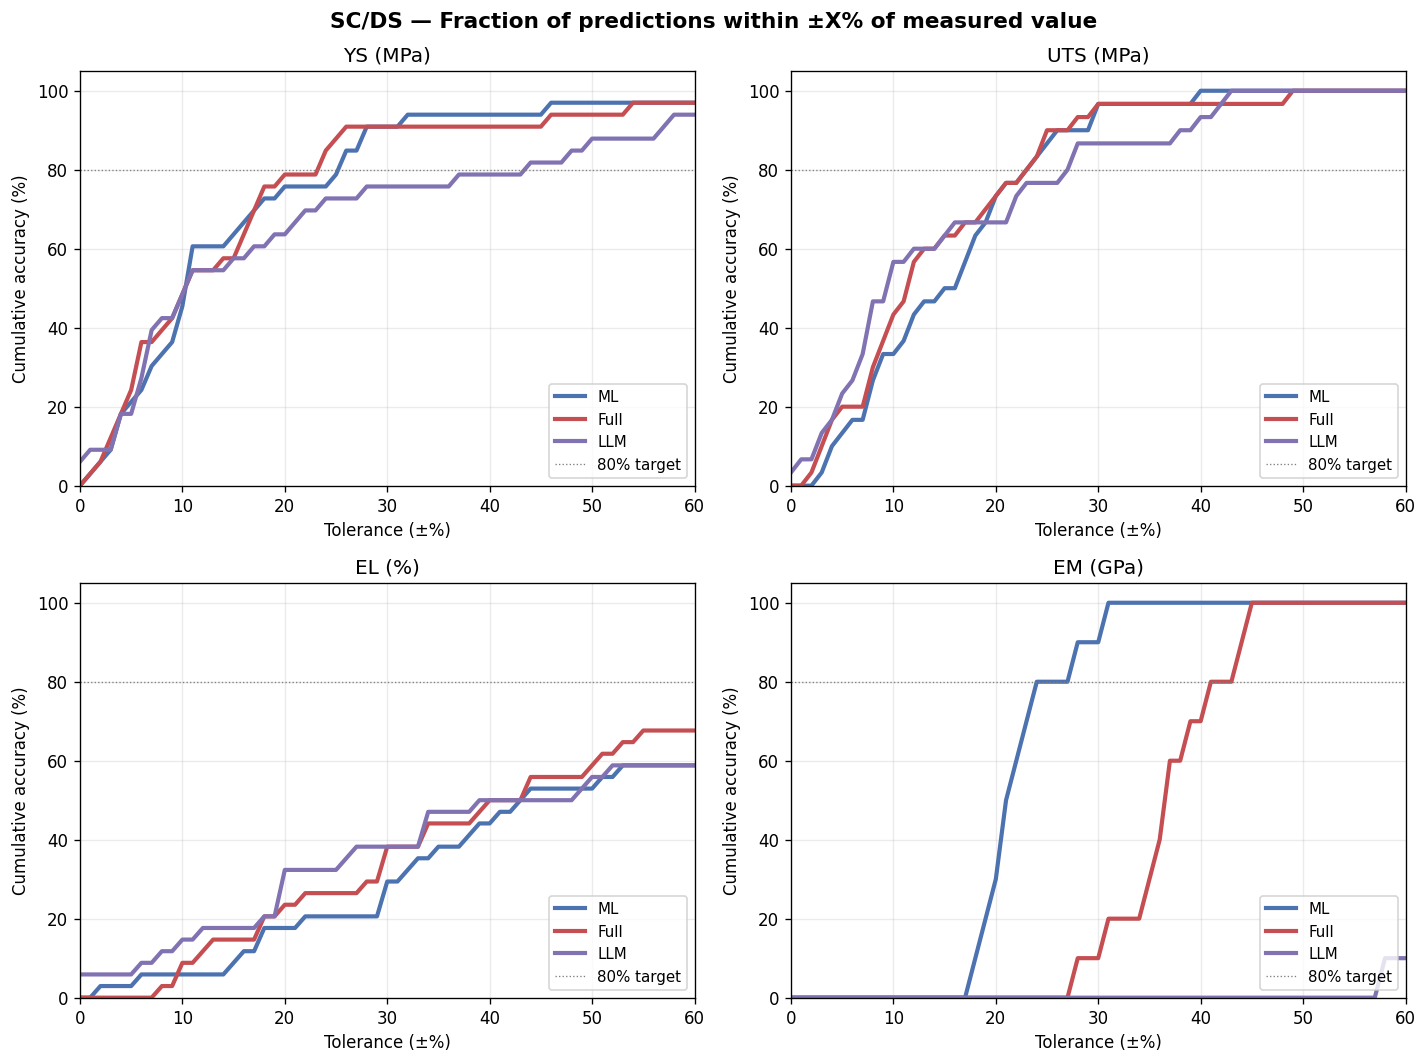

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    for mn, df in PLOT_METHODS.items():
        acc = [pct_within(df, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (±%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('SC/DS — Fraction of predictions within ±X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

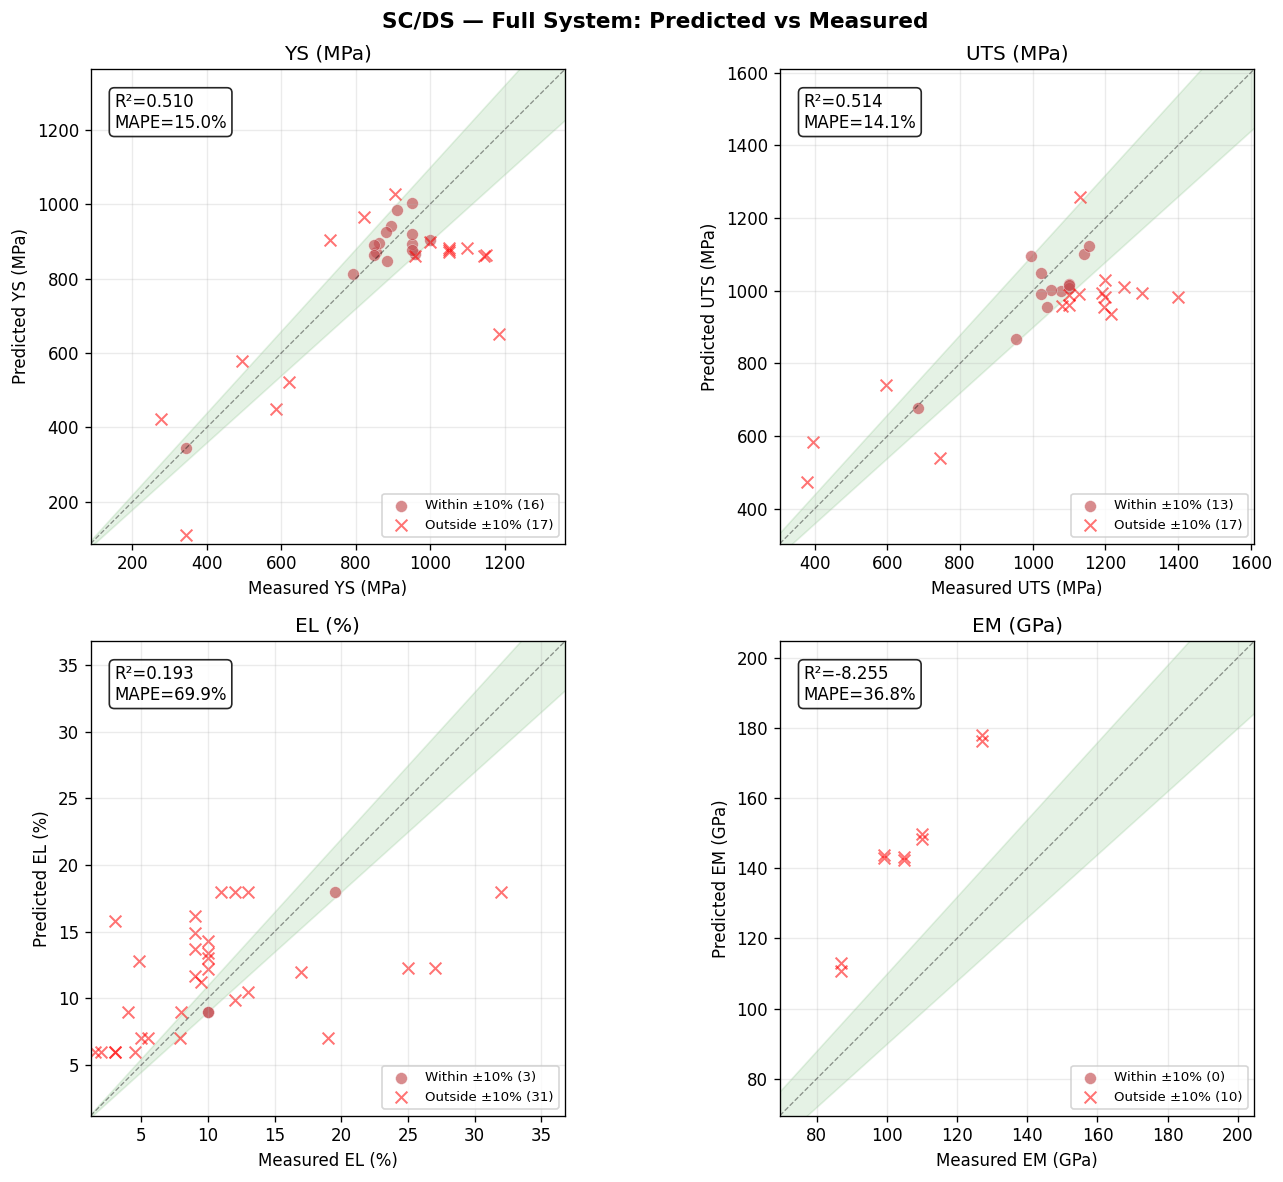

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    if len(v) < 2:
        ax.text(0.5, 0.5, 'Insufficient data', transform=ax.transAxes,
                ha='center', fontsize=11)
        ax.set(title=lbl)
        continue
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=50, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within ±10% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=50, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside ±10% ({(~w).sum()})')

    ax.text(0.05, 0.95, f"R²={m['r2']:.3f}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('SC/DS — Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Case Studies: Temperature Sweeps

PWA\*1480 and René N5 — the two SC alloys with full RT–1093°C coverage. YS and UTS predictions against published datasheet values.

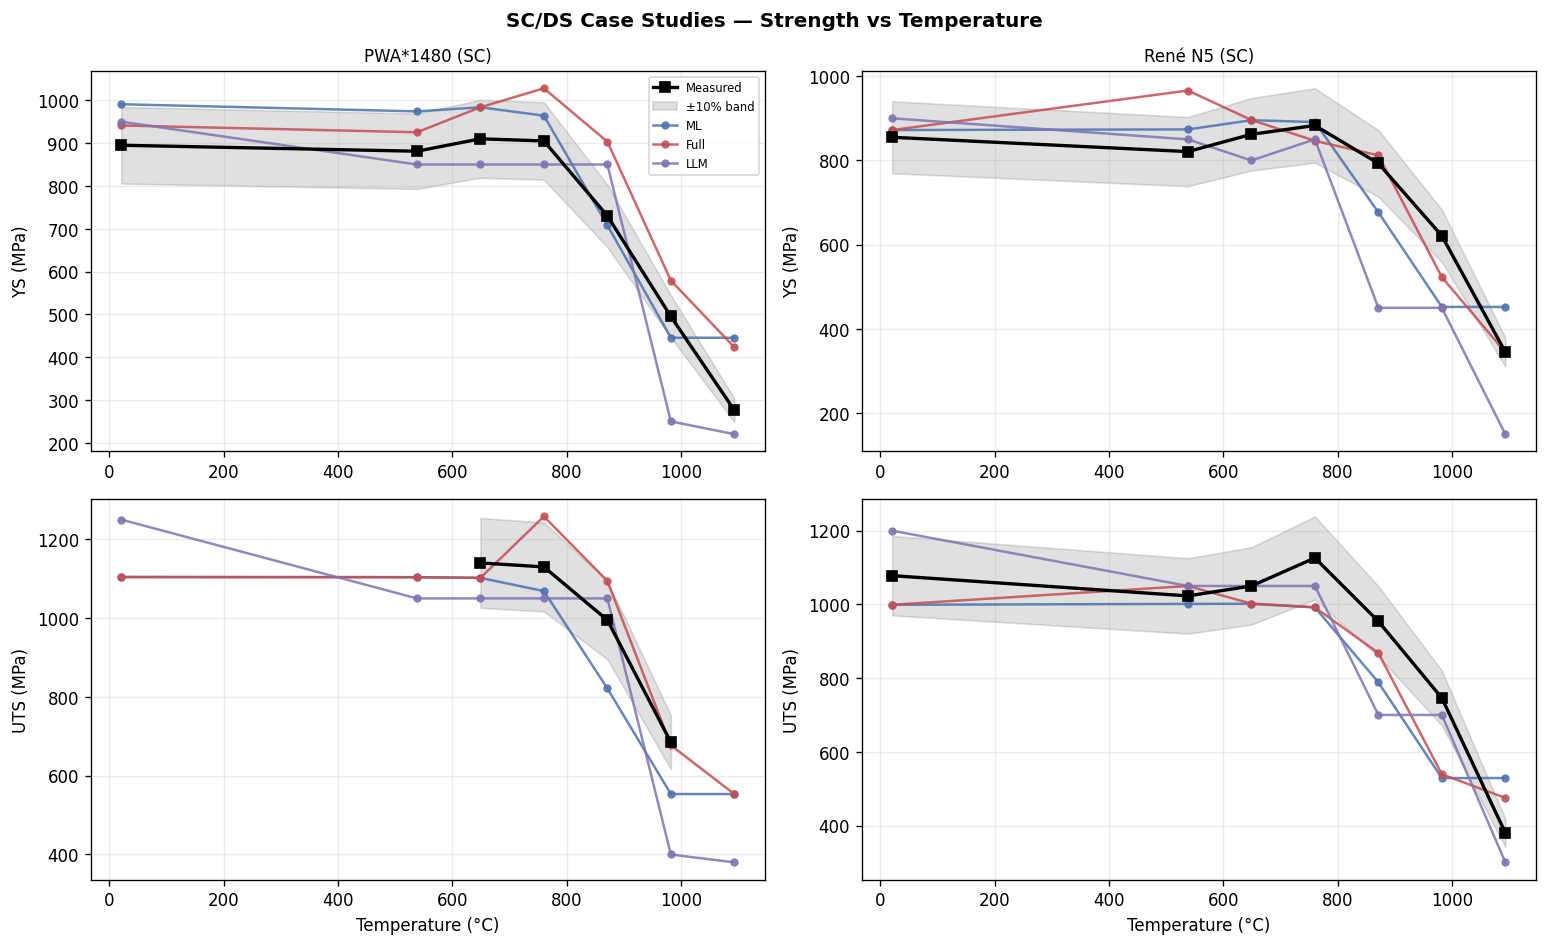

In [6]:
cases = ['PWA*1480(SC)', 'REN\u00c9* N5(SC)']
short_names = ['PWA*1480 (SC)', 'Ren\u00e9 N5 (SC)']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('SC/DS Case Studies \u2014 Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in ['ML', 'Full', 'LLM']:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()